# Credit Card Fraud Detection using Gaussian Mixture Models


In this project, we try to predict fraud from a dataset with PCA-transformed features through the usage of different iterations of GMMs:
 - An Unsupervised GMM which models the overall distribution of data using one or more components
 - A Semi-supervised (one-class kind) GMM that only learns from the non-fraud transactions
 - A Supervised version where we fit a GMM each for fraud and non-fraud transactions.

Because the features are PCA-transformed, there is a disadvantage of not being able to uncover real-world implications of credit card fraud data, but to the extent possible, let us try to incorporate elements that would be important from a real-world fraud domain perspective:
 - Time-ordered split - instead of a random stratified split, ie training only on the past, validating/testing on the future
 - Usage of KS test for feature selection, something actively used for real-world fraud detection
 - Implementation (and higher importance) of PR-AUC rather than ROC-AUC, since ROC-AUC is known to look optimistic under heavy class imbalance.
 - Fraud probability, calculated through Bayesian probability 
 - Calibration of the calculated probabilities (through a calibration curve and brier score)



In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set(color_codes=True)

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                              f1_score, precision_score, recall_score, confusion_matrix,
                              brier_score_loss)
from sklearn.calibration import calibration_curve
from scipy.special import logsumexp
from scipy import stats

plt.rcParams['figure.figsize'] = (8, 4)
RANDOM_STATE = 42

##  Importing and EDA

**Importing**

In [24]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Shape of the data**

In [25]:
print(df.shape)

(284807, 31)


**Distribution across fraud and non-fraud data**

In [26]:
class_counts = df['Class'].value_counts()
print(class_counts)
print((class_counts / sum(class_counts) * 100))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: count, dtype: float64


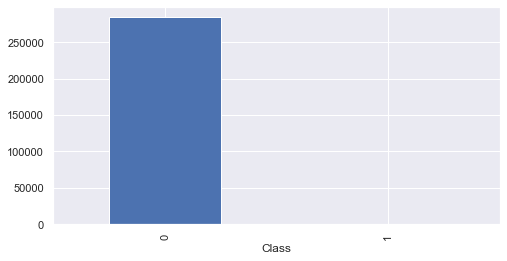

In [27]:
ax = class_counts.plot(kind='bar')
plt.show()

Only 0.17% of transactions are fraudulent. This is a highly imbalanced dataset

**Descriptives**

In [28]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Correlation between features**

<AxesSubplot:>

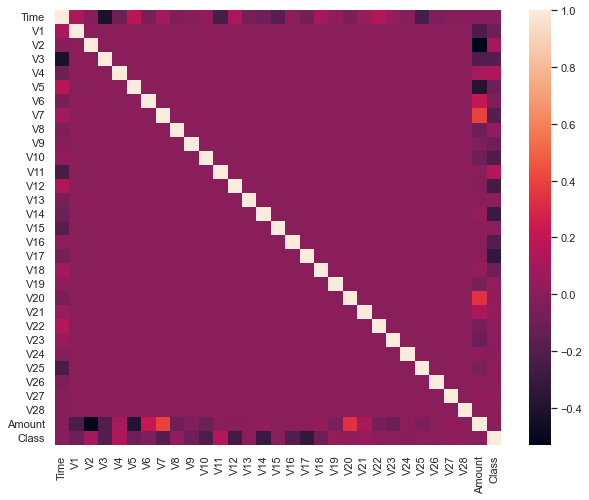

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr())

In [30]:
corr_top_5_absolute = df.corr()['Class'].abs().nlargest(5)
corr_top_5_with_signs = df.corr()['Class'].loc[corr_top_5_absolute.index]

corr_top_5_with_signs

Class    1.000000
V17     -0.326481
V14     -0.302544
V12     -0.260593
V10     -0.216883
Name: Class, dtype: float64

All features have moderate to weak correlation with the class variable

## Preprocessing

**Train/Validation/Test Split**

Rather than a random stratified split, we split the data chronologically: fit on the earliest ~70% of transactions, tune thresholds on the next ~15%, and report final metrics on the last ~15%. This is to make sure we go by a realistic approach (train on past, test on future) and not potentially benefit from information of future transactions

In [31]:
df_sorted = df.sort_values('Time').reset_index(drop=True)
n = len(df_sorted)
i1, i2 = int(n * 0.70), int(n * 0.85)

train_df = df_sorted.iloc[:i1]
val_df   = df_sorted.iloc[i1:i2]
test_df  = df_sorted.iloc[i2:]

X = df.drop(columns=['Class'])
X_train, y_train   = train_df.drop(columns=['Class']), train_df['Class']
X_val, y_val   = val_df.drop(columns=['Class']),   val_df['Class']
X_test, y_test = test_df.drop(columns=['Class']),  test_df['Class']

for name, d, yy in [('train', train_df, y_train), ('val', val_df, y_val), ('test', test_df, y_test)]:
    print(f'{name:5s}: n={len(d):>7,}  time=[{d.Time.min():>8.0f}, {d.Time.max():>8.0f}]  '
          f'fraud n={yy.sum():>4d}  fraud rate={yy.mean()*100:.4f}%')

train: n=199,364  time=[       0,   132928]  fraud n= 384  fraud rate=0.1926%
val  : n= 42,721  time=[  132929,   151328]  fraud n=  56  fraud rate=0.1311%
test : n= 42,722  time=[  151328,   172792]  fraud n=  52  fraud rate=0.1217%


**Scaling**

Standard Scaler is fit only on the train set's mean/std and applied unchanged to validation and test - the same fixed transformation everywhere, since that's the only scaling information actually available at prediction time in production.

In [32]:
scaler = StandardScaler().fit(X_train)
cols = X.columns
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=cols, index=X_train.index)
X_val_s = pd.DataFrame(scaler.transform(X_val), columns=cols, index=X_val.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=cols, index=X_test.index)

**Feature Selection (shared across all three models)**

We follow industry-standard of using KS Test (Kolmogorov-Smirnov) test. In this case, it meausures the separation between the distribution of a feature for legitimate transactions versus fraudulent transactions, helping us choose the features with the most discriminatory power. Let's choose 6 features since our fraud data has only 384 transactions and excessive features could lead to loss of degrees of freedom.

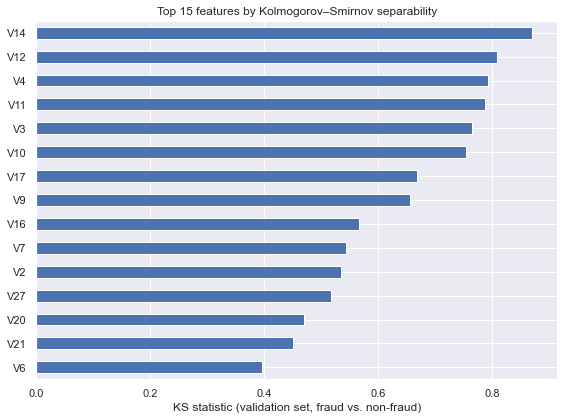

Selected top 6 features by KS statistic: ['V14', 'V12', 'V4', 'V11', 'V3', 'V10']


In [33]:

ks_scores = {}
for feat in cols:
    stat, p_value = stats.ks_2samp(
        X_val_s[feat][y_val.values == 0],  
        X_val_s[feat][y_val.values == 1]   
    )
    ks_scores[feat] = stat

ks_series = pd.Series(ks_scores).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ks_series.head(15).plot(kind='barh', ax=ax, color='#4C72B0')
ax.invert_yaxis()
ax.set_xlabel('KS statistic (validation set, fraud vs. non-fraud)')
ax.set_title('Top 15 features by Kolmogorov–Smirnov separability')
plt.tight_layout()
plt.show()

SELECTED_FEATURES = ks_series.head(6).index.tolist()
print(f'Selected top {len(SELECTED_FEATURES)} features by KS statistic: {SELECTED_FEATURES}')

In this case, 6 seems to be a good threshold also because we see a drop in values after V10

## Common Evaluation Framework

In [34]:
def tune_threshold(y_true_val, scores_val):
    precisions, recalls, thresholds = precision_recall_curve(y_true_val, scores_val)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_idx = np.argmax(f1s[:-1])
    return thresholds[best_idx], f1s[best_idx]

def evaluate(y_true, scores, threshold, model_name):
    preds = (scores >= threshold).astype(int)
    result = {
        'model': model_name,
        'roc_auc': roc_auc_score(y_true, scores),
        'pr_auc': average_precision_score(y_true, scores),
        'f1': f1_score(y_true, preds),
        'precision': precision_score(y_true, preds),
        'recall': recall_score(y_true, preds),
        'threshold': threshold,
    }
    cm = confusion_matrix(y_true, preds)
    return result, cm

def plot_confusion(cm, model_name, ax):
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred: Normal', 'Pred: Fraud'],
                yticklabels=['True: Normal', 'True: Fraud'])
    ax.set_title(model_name)

def plot_score_distributions(scores, y_true, model_name, ax):
    sns.histplot(scores[y_true == 0], bins=40, stat='density', color='#4C72B0',
                 label='Non-Fraud', ax=ax, alpha=0.5)
    sns.kdeplot(scores[y_true == 1], color='#C44E52', label='Fraud', ax=ax,
                linewidth=2, fill=True, alpha=0.4)
    sns.rugplot(scores[y_true == 1], color='#C44E52', ax=ax, height=0.05)
    ax.set_title(f'{model_name}: anomaly score distribution')
    ax.set_xlabel('Anomaly score (higher = more fraud-like)')
    ax.legend()

results = []


## Model A - Unsupervised GMM

No labels used at all. One mixture fit on the full (unlabeled) fit set; component count chosen by BIC on that unlabeled data.

In [35]:
Xf = X_train_s[SELECTED_FEATURES]
Xv = X_val_s[SELECTED_FEATURES]
Xt = X_test_s[SELECTED_FEATURES]

bic_scores = {}
for n_ in [1, 2, 3, 4, 5]:
    gm = GaussianMixture(n_components=n_, random_state=RANDOM_STATE,  n_init=10, reg_covar=1e-5).fit(Xf)
    bic_scores[n_] = gm.bic(Xf)
best_n_unsup = min(bic_scores, key=bic_scores.get)
print('BIC by n_components (unlabeled fit data):', bic_scores)
print('Selected n_components:', best_n_unsup)

gm_unsup = GaussianMixture(n_components=best_n_unsup, random_state=RANDOM_STATE,  n_init=10, reg_covar=1e-5).fit(Xf)

val_scores_unsup = -gm_unsup.score_samples(Xv)
threshold_unsup, val_f1_unsup = tune_threshold(y_val, val_scores_unsup)
print(f'Validation-tuned threshold: {threshold_unsup:.3f} (val F1={val_f1_unsup:.4f})')

test_scores_unsup = -gm_unsup.score_samples(Xt)
res_unsup, cm_unsup = evaluate(y_test, test_scores_unsup, threshold_unsup, 'Unsupervised GMM')
results.append(res_unsup)
res_unsup

BIC by n_components (unlabeled fit data): {1: 3391516.8817764437, 2: 2913949.100160701, 3: 2784717.455110696, 4: 2737410.4668210833, 5: 2647818.8831873946}
Selected n_components: 5
Validation-tuned threshold: 18.838 (val F1=0.2209)


{'model': 'Unsupervised GMM',
 'roc_auc': 0.9515287267220709,
 'pr_auc': 0.19435507232463403,
 'f1': 0.25287356321839083,
 'precision': 0.18032786885245902,
 'recall': 0.4230769230769231,
 'threshold': 18.837574555171365}

Note: Since we fit multiple GMMs, the overall distribution is a sum of all of the disributions, weighted. Hence, for every new transaction that we want to assess, we find out the probability density assigned by each gaussian and conclude whether it fits well in the overall distribution or seems off.

In [36]:


Xf = X_train_s[SELECTED_FEATURES]
Xv = X_val_s[SELECTED_FEATURES]
Xt = X_test_s[SELECTED_FEATURES]

bic_scores = {}
for n_ in range(1,11):
    gm = GaussianMixture(n_components=n_, random_state=RANDOM_STATE, n_init=10, reg_covar=1e-5).fit(Xf)
    bic_scores[n_] = gm.bic(Xf).round(3)
best_n_unsup = min(bic_scores, key=bic_scores.get)
print('BIC by n_components (unlabeled fit data):', bic_scores)
print('Selected n_components:', best_n_unsup)

gm_unsup = GaussianMixture(n_components=best_n_unsup, random_state=RANDOM_STATE, n_init=10, reg_covar=1e-5).fit(Xf)

val_scores_unsup = -gm_unsup.score_samples(Xv)
threshold_unsup, val_f1_unsup = tune_threshold(y_val, val_scores_unsup)
print(f'Validation-tuned threshold: {threshold_unsup:.3f} (val F1={val_f1_unsup:.4f})')

test_scores_unsup = -gm_unsup.score_samples(Xt)
res_unsup, cm_unsup = evaluate(y_test, test_scores_unsup, threshold_unsup, 'Unsupervised GMM')
results.append(res_unsup)
res_unsup



"\n\nXf = X_train_s[SELECTED_FEATURES]\nXv = X_val_s[SELECTED_FEATURES]\nXt = X_test_s[SELECTED_FEATURES]\n\nbic_scores = {}\nfor n_ in range(1,11):\n    gm = GaussianMixture(n_components=n_, random_state=RANDOM_STATE, n_init=10, reg_covar=1e-5).fit(Xf)\n    bic_scores[n_] = gm.bic(Xf).round(3)\nbest_n_unsup = min(bic_scores, key=bic_scores.get)\nprint('BIC by n_components (unlabeled fit data):', bic_scores)\nprint('Selected n_components:', best_n_unsup)\n\ngm_unsup = GaussianMixture(n_components=best_n_unsup, random_state=RANDOM_STATE, n_init=10, reg_covar=1e-5).fit(Xf)\n\nval_scores_unsup = -gm_unsup.score_samples(Xv)\nthreshold_unsup, val_f1_unsup = tune_threshold(y_val, val_scores_unsup)\nprint(f'Validation-tuned threshold: {threshold_unsup:.3f} (val F1={val_f1_unsup:.4f})')\n\ntest_scores_unsup = -gm_unsup.score_samples(Xt)\nres_unsup, cm_unsup = evaluate(y_test, test_scores_unsup, threshold_unsup, 'Unsupervised GMM')\nresults.append(res_unsup)\nres_unsup\n\n"

Interesting find - PR AUC and recall drops in the n9 model compared to the n5 model. This is because PR AUC ranks the model at every possible threshold as opposed to evaluating it at a single threshold. Given the small number of fraud transactions, its better not to entirely trust a single threshold point, and go for the one that gives a better distinction at more than 1 possible threshold points to reduce the impact of any small sample noise. 

Let us hence go with the n5 model for the remaining for consistency

## Model B - Semi-Supervised GMM (Non-fraud data only)

Fit exclusively on non-fraud fit-set rows; the model never sees a fraud example during training (this is realistic considering that we may have few labelled fraud data in real life cases)

In [37]:
Xf_normal = Xf[y_train.values == 0]

bic_scores_semi = {}
for n_ in [1, 2, 3, 4, 5]:
    gm = GaussianMixture(n_components=n_, random_state=42,  n_init=10, reg_covar=1e-5).fit(Xf_normal)
    bic_scores_semi[n_] = gm.bic(Xf_normal)
best_n_semi = min(bic_scores_semi, key=bic_scores_semi.get)
print('BIC by n_components (non-fraud fit data only):', bic_scores_semi)
print('Selected n_components:', best_n_semi)

gm_semi = GaussianMixture(n_components=best_n_semi, random_state=42,  n_init=10, reg_covar=1e-5).fit(Xf_normal)

val_scores_semi = -gm_semi.score_samples(Xv)
threshold_semi, val_f1_semi = tune_threshold(y_val, val_scores_semi)
print(f'Validation-tuned threshold: {threshold_semi:.3f} (val F1={val_f1_semi:.4f})')

test_scores_semi = -gm_semi.score_samples(Xt)
res_semi, cm_semi = evaluate(y_test, test_scores_semi, threshold_semi, 'Semi-supervised GMM')
results.append(res_semi)
res_semi

BIC by n_components (non-fraud fit data only): {1: 3246432.9157048957, 2: 2858012.6232176055, 3: 2764270.250996555, 4: 2680793.506946887, 5: 2624929.839588076}
Selected n_components: 5
Validation-tuned threshold: 22.945 (val F1=0.4511)


{'model': 'Semi-supervised GMM',
 'roc_auc': 0.9555051288060429,
 'pr_auc': 0.4595835237692771,
 'f1': 0.44642857142857145,
 'precision': 0.4166666666666667,
 'recall': 0.4807692307692308,
 'threshold': 22.944967975103943}

Much better scores overall - which show that training on just non-fraud data instead of both improves scores. Training on just non-fraud data helps the model understand and distinguish fraud vs non-fraud transactions much better.

## Model C - Supervised GMM

Two mixtures - one on non-fraud fit data, one on fraud fit data

In [38]:
Xf_fraud = Xf[y_train.values == 1]
print(f'Fraud rows available for fitting: {len(Xf_fraud)}')

bic_scores_fraud = {}
for n_ in [1, 2, 3]:
    gm = GaussianMixture(n_components=n_, random_state=RANDOM_STATE,  n_init=10, reg_covar=1e-4).fit(Xf_fraud)
    bic_scores_fraud[n_] = gm.bic(Xf_fraud)
best_n_fraud = min(bic_scores_fraud, key=bic_scores_fraud.get)
print('BIC by n_components (fraud fit data only):', bic_scores_fraud)
print('Selected n_components (fraud side):', best_n_fraud, '| (normal side, reused from Model B):', best_n_semi)

gm_normal_sup = GaussianMixture(n_components=best_n_semi, random_state=RANDOM_STATE,  n_init=10, reg_covar=1e-5).fit(Xf_normal)
gm_fraud_sup = GaussianMixture(n_components=best_n_fraud, random_state=RANDOM_STATE,  n_init=10, reg_covar=1e-4).fit(Xf_fraud)

val_scores_sup = gm_fraud_sup.score_samples(Xv) - gm_normal_sup.score_samples(Xv)
threshold_sup, val_f1_sup = tune_threshold(y_val, val_scores_sup)
print(f'Validation-tuned threshold: {threshold_sup:.3f} (val F1={val_f1_sup:.4f})')

test_scores_sup = gm_fraud_sup.score_samples(Xt) - gm_normal_sup.score_samples(Xt)
res_sup, cm_sup = evaluate(y_test, test_scores_sup, threshold_sup, 'Supervised GMM')
results.append(res_sup)
res_sup

Fraud rows available for fitting: 384
BIC by n_components (fraud fit data only): {1: 10140.916474973323, 2: 9375.374712416273, 3: 9251.820623473399}
Selected n_components (fraud side): 3 | (normal side, reused from Model B): 5
Validation-tuned threshold: 6.757 (val F1=0.7965)


{'model': 'Supervised GMM',
 'roc_auc': 0.967889527861405,
 'pr_auc': 0.6316699570258201,
 'f1': 0.7307692307692307,
 'precision': 0.7307692307692307,
 'recall': 0.7307692307692307,
 'threshold': 6.757284963318936}

We use 3 components here instead of 5 like the previous ones to account for the fact that we fit GMMs on the fraud dataset as well (just 384 cases). Since we need 5 parameters for 3 components, that's 15 parameters estimated. Hence, we've used 3 to reduce loss of degrees of freedom.

Overall, this model gives the best scores all-round, which shows the fitting GMMs on the fraud data helps a lot with identifying more such frauds

##  Fraud Probability (Supervised Model)

Something cool about GMMs is that we are able to learn the underlying distribution of the data itself (in this case fraud and non-fraud data). And with those distributions, we're able to generate likelihood and a fraud probability. Any observation can be passed through the fraud and non-fraud distributions that we have learned to find out where it could land.

Because we can answer questions like, what's the probability of fraud and non fraud data in our dataset (priors), how well does a transaction fit the fraud distribution given it's fraudulent P(x | fraud) and a normal transaction to the non-fraud distribution we've modelled P(x | non-fraud), we can construct the posterior fraud probability that tells us what is the chance of a transaction being fraudulent

In [39]:
prior_fraud = y_train.mean()
prior_normal = 1 - prior_fraud
print(f'Prior P(fraud) from fit set: {prior_fraud:.5f}')

def posterior_fraud(X_selected_df):
    log_lik_fraud = gm_fraud_sup.score_samples(X_selected_df) + np.log(prior_fraud)
    log_lik_normal = gm_normal_sup.score_samples(X_selected_df) + np.log(prior_normal)
    log_denominator = logsumexp(np.vstack([log_lik_fraud, log_lik_normal]), axis=0)
    return np.exp(log_lik_fraud - log_denominator)

p_fraud_test = posterior_fraud(Xt)
print('PR-AUC using the posterior directly as a ranking score:', average_precision_score(y_test, p_fraud_test))

pd.DataFrame({
    'true_class': y_test.values,
    'p_fraud': p_fraud_test
}).sort_values('p_fraud', ascending=False).head(10)

Prior P(fraud) from fit set: 0.00193
PR-AUC using the posterior directly as a ranking score: 0.6348750852309484


,true_class,p_fraud
32686,0,1.0
20741,1,1.0
21187,1,1.0
10039,1,1.0
7878,1,1.0
8676,1,1.0
10689,1,1.0
9392,1,1.0
1614,1,1.0
1664,1,1.0


We use Bayesian probability to calculate the probability of a transaction being fraudulent. This is beacuse we get the log probability density of each observation through score_samples() (ie, how well does each observation fit the fraud and non-fraud GMM distributions). Using these, along with the fraud and non-fraud proportions, we can find P(fraud | transaction) as:

[P(transaction | fraud)* P(fraud)]/[P(transaction | fraud)* P(fraud) + P(transaction | non-fraud)* P(non-fraud)]

Note that we convert the proportions to log as well, since we start with log probability densities. We then convert it back to understandable probability using np.exp()

## Calbration Curve/Reliability Diagram


Now that we have probabilities, let us assess if they are reliable. We can plot the calibration curve on the probabilities we created to see if model predictions of probability and actual frequency match

We are also calculating Brier score which tells us how close are the predicted probabilities to actual outcome (essentially the mean squared error between predicted probability and the true outcome). It ranges from 0 (perfect calibration to 1 (worst calibration)


Brier score: 0.000677


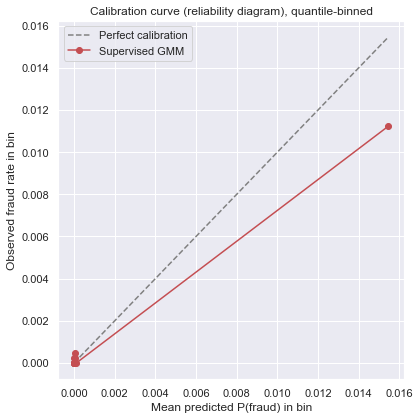

,mean_predicted,observed_fraud_rate
0,5.290433e-07,0.000000
1,1.770161e-06,0.000000
2,2.935756e-06,0.000000
3,4.526528e-06,0.000000
4,7.517541e-06,0.000234
5,1.391665e-05,0.000000
6,2.739805e-05,0.000234
7,5.202782e-05,0.000468
8,1.123113e-04,0.000000
9,1.546103e-02,0.011233


In [40]:
brier = brier_score_loss(y_test, p_fraud_test)
print(f'Brier score: {brier:.6f}')

frac_positive, mean_predicted = calibration_curve(y_test, p_fraud_test, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, mean_predicted.max()], [0, mean_predicted.max()], linestyle='--', color='gray', label='Perfect calibration')
ax.plot(mean_predicted, frac_positive, marker='o', color='#C44E52', label='Supervised GMM')
ax.set_xlabel('Mean predicted P(fraud) in bin')
ax.set_ylabel('Observed fraud rate in bin')
ax.set_title('Calibration curve (reliability diagram), quantile-binned')
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({'mean_predicted': mean_predicted, 'observed_fraud_rate': frac_positive})

The surpervised GMM deviates more and more as the frequency of fraud increases and stays below the perfect calibration curve, which implies that model is generally overpredicting fraud. Hence, caution must be exercised while considering these as final probabilities (however, overpredicting non-fraud as fraud tells us that the model is being cautious, and its better than the other way round). The Brier score is quite low which tells us that the deviation is not too concerning.

## Comparison

In [41]:
results_df = pd.DataFrame(results).set_index('model')[['roc_auc', 'pr_auc', 'precision', 'recall', 'f1', 'threshold']]
results_df = results_df.round(4)
results_df

,roc_auc,pr_auc,precision,recall,f1,threshold
model,,,,,,
Unsupervised GMM,0.9515,0.1944,0.1803,0.4231,0.2529,18.8376
Semi-supervised GMM,0.9555,0.4596,0.4167,0.4808,0.4464,22.9450
Supervised GMM,0.9679,0.6317,0.7308,0.7308,0.7308,6.7573


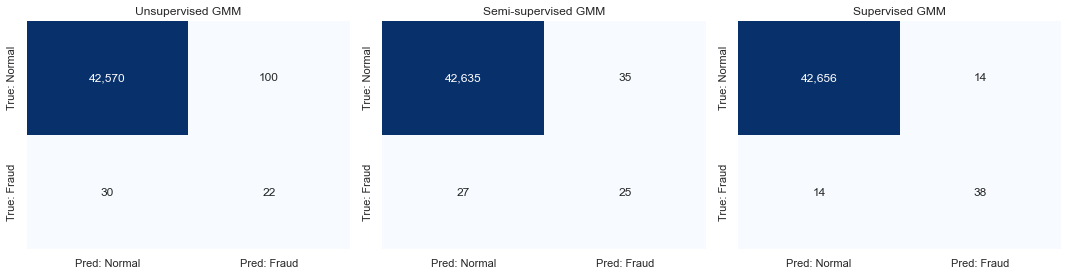

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (cm, name) in zip(axes, [(cm_unsup, 'Unsupervised GMM'),
                                   (cm_semi, 'Semi-supervised GMM'),
                                   (cm_sup, 'Supervised GMM')]):
    plot_confusion(cm, name, ax)
plt.tight_layout()
plt.show()

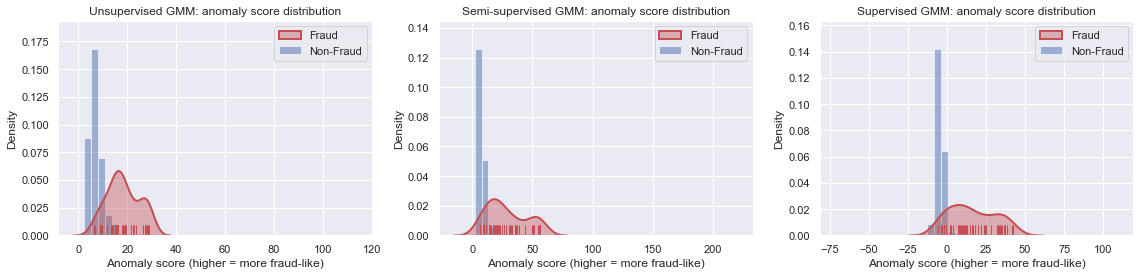

In [44]:
pd._config.config.register_option('mode.use_inf_as_null', False, 'Patch for legacy dependencies')

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (scores, name) in zip(axes, [(test_scores_unsup, 'Unsupervised GMM'),
                                       (test_scores_semi, 'Semi-supervised GMM'),
                                       (test_scores_sup, 'Supervised GMM')]):
    plot_score_distributions(scores, y_test.values, name, ax)
plt.tight_layout()
plt.show()

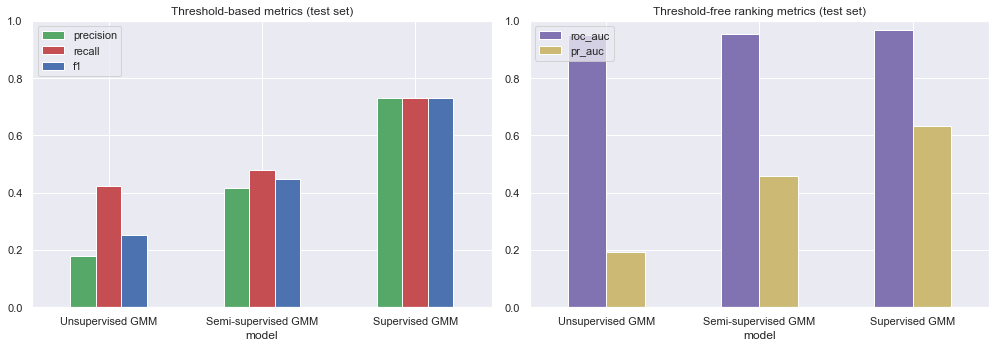

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df[['precision', 'recall', 'f1']].plot(kind='bar', ax=axes[0], color=['#55A868', '#C44E52', '#4C72B0'])
axes[0].set_title('Threshold-based metrics (test set)')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

results_df[['roc_auc', 'pr_auc']].plot(kind='bar', ax=axes[1], color=['#8172B2', '#CCB974'])
axes[1].set_title('Threshold-free ranking metrics (test set)')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

We can see that supervised GMM has better metrics overall - indicating labelled data for model performance can be important for fraud detection performance. Unsupervised GMM clearly doesnt give a great result here. Semi-supervised despite showing decent improvement in precision and f1 doesnt show a significant improvement in recall.

An interesting observation is the behaviour of PR-AUC vs ROC-AUC. There is not much of a significant change in ROC-AUC across the 3 scenerios, but PR-AUC visibly changes as we transition from unsupervised to supervised. It is easy to get an attractive AUC score without accounting for the heavy imbalance in the data which PR-AUC handles well.

Limitations

 - The dataset is already processed and modelled, hence we're not directly working with realistic credit card fraud data and are unaware of implications of actual features on detecting fraud
 - The objective was to see how a density based model like GMM performs in fraud detection, and so other algorithms/alternatives have not been used to improve performance
 - Since we also employ unsupervised learning, we had to start with BIC as the metric to choose the number of components. Exploration of other mechanisms (such as maximizing f1 score) is also worth checking but is beyond the scope of this project.